# Exploratory Data Analysis — S&P 500 Volatility Project

This notebook provides the dedicated Stage 8 EDA evidence for the final project. It reuses the reusable project EDA helpers rather than duplicating all logic in notebook cells.

## 1. Load model-ready / cleaned project data

What it shows: the project-level modeling table and cleaned aligned market table are available.

Why it matters: EDA should inspect the actual data used by the prediction workflow.

Limitation / assumption: the table is generated by the current pipeline run and reflects public source availability through the configured end date.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import masked_config_status
from src.eda import eda_summary, save_eda_figures, save_eda_tables

print(masked_config_status())
model_ready = pd.read_csv(PROJECT_ROOT / "data/processed/model_ready_volatility.csv", parse_dates=["date"])
cleaned = pd.read_csv(PROJECT_ROOT / "data/processed/market_data_cleaned.csv", parse_dates=["date"])
print({"model_ready_rows": len(model_ready), "cleaned_rows": len(cleaned)})

{'project_root': '.', 'data_dir': 'data', 'raw_data_dir': 'data/raw', 'processed_data_dir': 'data/processed', 'reports_dir': 'reports', 'model_dir': 'model', 'docs_dir': 'docs', 'env_file_present': 'False'}
{'model_ready_rows': 2148, 'cleaned_rows': 2173}


## 2. Data structure

What it shows: shape, date coverage, dtypes, and missingness.

Why it matters: model validity depends on aligned dates and complete predictor/target columns.

Limitation / assumption: Treasury observations can be forward-filled after date alignment, as documented in preprocessing.

In [2]:
summary = eda_summary(model_ready)
print({"shape": summary["shape"], "date_min": summary["date_min"], "date_max": summary["date_max"]})
display(pd.DataFrame({"dtype": summary["dtypes"], "missing_count": summary["missing"]}).head(20))

{'shape': (2148, 27), 'date_min': '2018-02-01', 'date_max': '2026-08-19'}


,dtype,missing_count
date,datetime64[us],0
sp500_open,float64,0
sp500_high,float64,0
sp500_low,float64,0
sp500_close,float64,0
sp500_volume,int64,0
vix_close,float64,0
treasury_10y,float64,0
treasury_2y,float64,0
sp500_return,float64,0


## 3. Summary statistics

What it shows: central tendency, dispersion, extremes, and skewness.

Why it matters: volatility and VIX are skewed risk variables, so averages alone are not enough.

Limitation / assumption: summary statistics describe the sample; they are not stable guarantees for future regimes.

In [3]:
numeric_summary = summary["numeric_summary"]
display(numeric_summary.loc[[
    "future_5d_realized_volatility",
    "realized_volatility_5d",
    "realized_volatility_21d",
    "vix_close",
    "treasury_10y",
    "treasury_2y",
    "yield_spread_10y_2y",
]].round(6))

,mean,median,std,min,max,skew
future_5d_realized_volatility,0.008570,0.007019,0.007039,0.000808,0.084519,4.451035
realized_volatility_5d,0.008592,0.007046,0.007047,0.000808,0.084519,4.432052
realized_volatility_21d,0.009987,0.008356,0.006529,0.003216,0.059530,3.907340
vix_close,19.768305,17.910000,7.234207,10.850000,82.690002,2.782870
treasury_10y,2.962933,3.040000,1.281371,0.520000,4.980000,-0.347746
treasury_2y,2.708208,2.850000,1.621902,0.090000,5.190000,-0.364540
yield_spread_10y_2y,0.254725,0.280000,0.538486,-1.080000,1.590000,-0.072254


## 4. Time-series visualization

What it shows: realized volatility and scaled VIX through time.

Why it matters: the model is intended to track risk regimes, not just average error.

Limitation / assumption: VIX is scaled by 100 only for visual comparison with daily volatility.

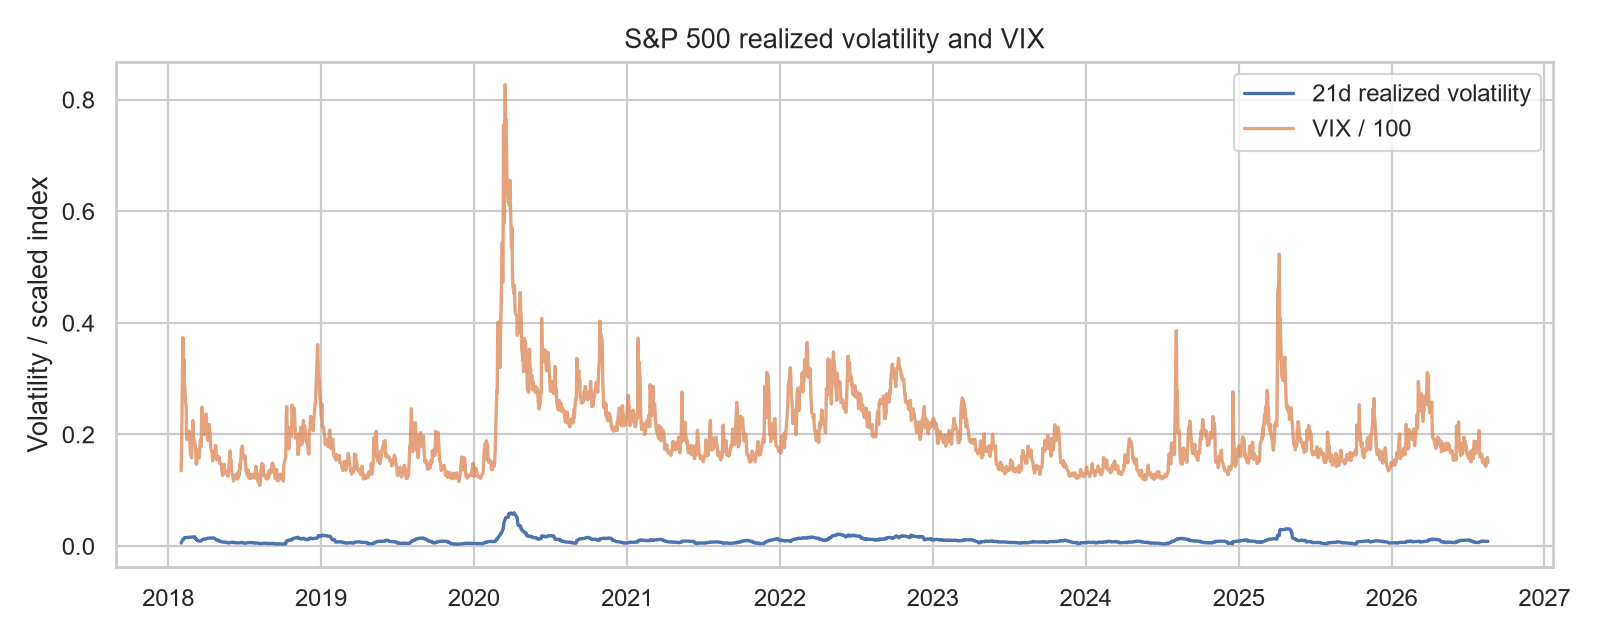

In [4]:
save_eda_tables(model_ready)
figures = save_eda_figures(model_ready)
display(Image(filename=str(PROJECT_ROOT / "reports/figures/eda_volatility_time_series.png")))

## 5. Relationship visualization

What it shows: VIX versus the next five-day realized volatility target.

Why it matters: VIX is a market-implied stress measure and should have predictive association with future realized volatility.

Limitation / assumption: the scatter plot is descriptive; it does not prove causality.

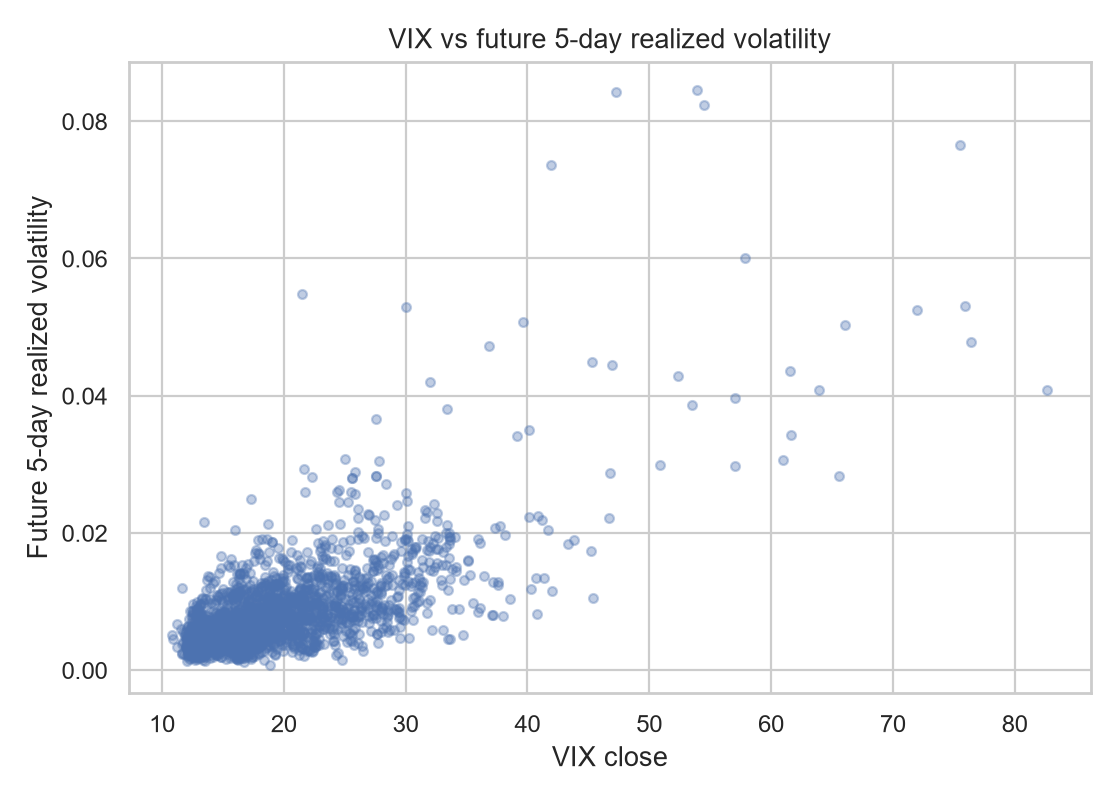

In [5]:
display(Image(filename=str(PROJECT_ROOT / "reports/figures/eda_vix_vs_future_vol.png")))

## 6. Correlation analysis

What it shows: pairwise correlations among major predictors and the target.

Why it matters: correlations help identify useful signals and multicollinearity risk before modeling.

Limitation / assumption: correlations are linear and unconditional, so they may miss nonlinear or regime-specific patterns.

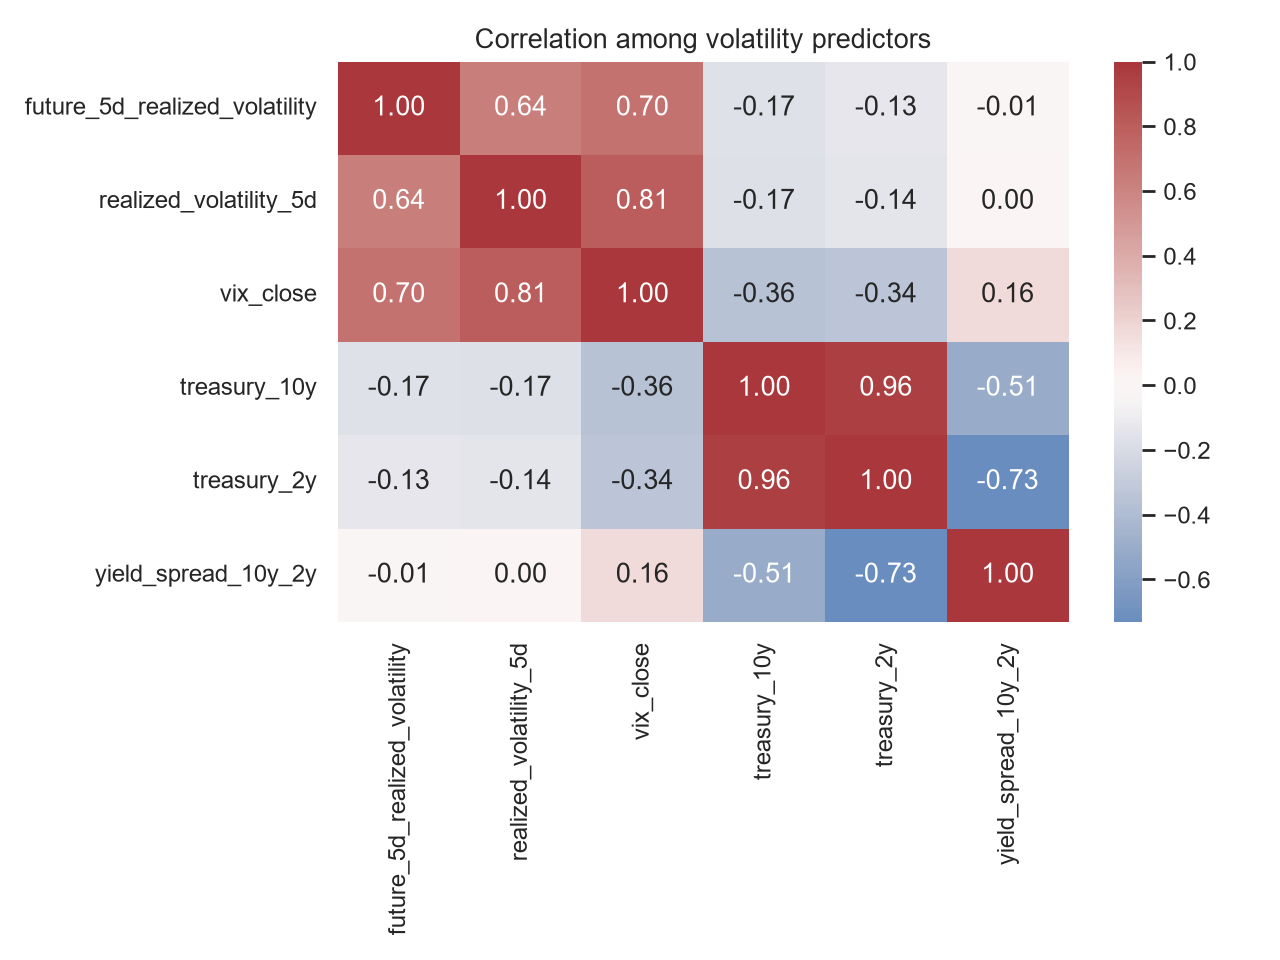

,future_5d_realized_volatility
future_5d_realized_volatility,1.000
vix_close,0.702
vix_x_realized_vol_5d,0.649
realized_volatility_5d,0.639
realized_volatility_10d,0.635
realized_volatility_21d,0.568
sp500_volume,0.386
vix_pct_change,0.146
vix_change,0.132
yield_spread_change_5d,0.062


In [6]:
display(Image(filename=str(PROJECT_ROOT / "reports/figures/eda_correlation_heatmap.png")))
corr = pd.read_csv(PROJECT_ROOT / "reports/tables/eda_correlation_matrix.csv", index_col=0)
display(corr[["future_5d_realized_volatility"]].sort_values("future_5d_realized_volatility", ascending=False).head(10).round(3))

## 7. Outlier / stress-regime observations

What it shows: how many observations are flagged as high-VIX, high-realized-volatility, or IQR outliers.

Why it matters: stress observations are decision-relevant and should be retained and flagged rather than deleted automatically.

Limitation / assumption: fixed quantile/IQR thresholds are transparent but may need recalibration in production.

In [7]:
flag_cols = [c for c in model_ready.columns if "outlier" in c or "regime" in c]
display(model_ready[flag_cols].mean().rename("share_of_rows").to_frame().round(4))
display(model_ready.sort_values("future_5d_realized_volatility", ascending=False)[
    ["date", "future_5d_realized_volatility", "vix_close", "realized_volatility_5d", "high_vix_regime", "high_realized_vol_regime"]
].head(10))

,share_of_rows
sp500_return_iqr_outlier,0.0126
realized_volatility_iqr_outlier,0.0196
high_vix_regime,0.2533
high_realized_vol_regime,0.2528


,date,future_5d_realized_volatility,vix_close,realized_volatility_5d,high_vix_regime,high_realized_vol_regime
529,2020-03-11,0.084519,53.900002,0.042059,True,True
528,2020-03-10,0.084323,47.299999,0.047295,True,True
527,2020-03-09,0.082348,54.459999,0.038045,True,True
530,2020-03-12,0.076485,75.470001,0.050789,True,True
526,2020-03-06,0.073572,41.939999,0.034973,True,True
531,2020-03-13,0.060038,57.830002,0.073572,True,True
1801,2025-04-02,0.054819,21.510000,0.009808,False,False
533,2020-03-17,0.053133,75.910004,0.084323,True,True
1802,2025-04-03,0.052942,30.020000,0.021351,True,True
535,2020-03-19,0.052461,72.000000,0.076485,True,True


## 8. Stakeholder-oriented EDA findings

- VIX and recent realized volatility are the most visibly relevant risk-state variables.
- Volatility is clustered and skewed, which supports using chronological validation instead of random splits.
- Stress rows should not be removed blindly because they represent the exact periods when a risk manager needs the model most.
- Treasury features are useful context, but sensitivity testing is needed to confirm whether the final model relies on them.